<a href="https://colab.research.google.com/github/dohaneedsrest/ECE-570-R-DROP-Project/blob/main/AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Project (Tiny Reproductions)**

**Step 0 : Enable GPU**

In [ ]:
!nvidia-smi

Sun Mar 29 20:24:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Step 1 : Install Packages**

In [ ]:
!pip -q install transformers datasets accelerate scikit-learn

**Step 2 : Baseline training notebook**

In [ ]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1) Load SST-2 (GLUE)
dataset = load_dataset("glue", "sst2")

# 2) Tokenizer: converts text -> numbers the model understands
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["sentence"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(dataset["train"], batch_size=16, shuffle=True)
val_loader   = DataLoader(dataset["validation"], batch_size=64)

# 3) Model: pretrained DistilBERT + classification head
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# 4) Evaluation function
def evaluate(model):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            logits = out.logits
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            labels.extend(batch["label"].cpu().tolist())
    return accuracy_score(labels, preds)

# 5) Train for 1 epoch (baseline)
model.train()
pbar = tqdm(train_loader, desc="Training (baseline, 1 epoch)")
for batch in pbar:
    batch = {k: v.to(device) for k, v in batch.items()}
    out = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        labels=batch["label"]
    )
    loss = out.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    pbar.set_postfix(loss=float(loss))

val_acc = evaluate(model)
print("Baseline validation accuracy:", val_acc)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training (baseline, 1 epoch):   0%|          | 0/4210 [00:00<?, ?it/s]

/tmp/ipykernel_4876/2361186910.py:61: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  pbar.set_postfix(loss=float(loss))


Baseline validation accuracy: 0.911697247706422


**Step 3 : Define the R-Drop loss**

In [ ]:
import torch.nn.functional as F

def rdrop_loss(logits1, logits2, labels, alpha=4.0):
    # Task loss (cross-entropy on both passes)
    ce = 0.5 * (
        F.cross_entropy(logits1, labels) +
        F.cross_entropy(logits2, labels))

    # Convert logits to log-probabilities
    logp1 = F.log_softmax(logits1, dim=-1)
    logp2 = F.log_softmax(logits2, dim=-1)
    p1, p2 = logp1.exp(), logp2.exp()

    # Symmetric KL divergence
    kl12 = F.kl_div(logp1, p2, reduction="batchmean")
    kl21 = F.kl_div(logp2, p1, reduction="batchmean")

    return ce + 0.5 * alpha * (kl12 + kl21)

**Step 4 : Train 1 epoch with R-Drop**

In [ ]:
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

def train_one_epoch_rdrop(model, optimizer, alpha=4.0):
    model.train()
    pbar = tqdm(train_loader, desc=f"Training (R-Drop, alpha={alpha}, 1 epoch)")
    for batch in pbar:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["label"]

        # Forward pass #1 (dropout sampled)
        out1 = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        logits1 = out1.logits

        # Forward pass #2 (different dropout sampled)
        out2 = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        logits2 = out2.logits

        loss = rdrop_loss(logits1, logits2, labels, alpha=alpha)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        pbar.set_postfix(loss=float(loss))

# Fresh model (important: fair comparison baseline vs rdrop)
model_rdrop = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)

optimizer_rdrop = AdamW(model_rdrop.parameters(), lr=2e-5)

train_one_epoch_rdrop(model_rdrop, optimizer_rdrop, alpha=4.0)

val_acc_rdrop = evaluate(model_rdrop)
print("R-Drop validation accuracy:", val_acc_rdrop)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training (R-Drop, alpha=4.0, 1 epoch):   0%|          | 0/4210 [00:00<?, ?it/s]

R-Drop validation accuracy: 0.8944954128440367


In [ ]:


model.train()

for batch in train_loader:
    batch = {k: v.to(device) for k, v in batch.items()}
    labels = batch["label"]

    # Forward pass 1 (dropout sampled)
    out1 = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )

    # Forward pass 2 (different dropout mask)
    out2 = model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"]
    )

    loss = rdrop_loss(out1.logits, out2.logits, labels)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
def train_and_track(model, optimizer, n_epochs=3, use_rdrop=False, alpha=4.0, label=""):
    """Train for n epochs, recording train_acc and val_acc each epoch."""
    history = {"train_acc": [], "val_acc": [], "gen_gap": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        all_preds, all_labels = [], []

        for batch in tqdm(train_loader, desc=f"[{label}] Epoch {epoch}/{n_epochs}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels_b = batch["label"]

            if use_rdrop:
                out1 = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
                out2 = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
                loss = rdrop_loss(out1.logits, out2.logits, labels_b, alpha=alpha)
                logits = out1.logits
            else:
                out = model(input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"], labels=labels_b)
                loss = out.loss
                logits = out.logits

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            all_preds.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
            all_labels.extend(labels_b.cpu().tolist())

        train_acc = accuracy_score(all_labels, all_preds)
        val_acc   = evaluate(model)
        gap       = train_acc - val_acc
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["gen_gap"].append(gap)
        print(f"[{label}] Epoch {epoch}: train={train_acc:.4f}, val={val_acc:.4f}, gap={gap:.4f}")

    return history

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Baseline] Epoch 1/3:   0%|          | 0/4210 [00:00<?, ?it/s]

[Baseline] Epoch 1: train=0.9163, val=0.8956, gap=0.0207


[Baseline] Epoch 2/3:   0%|          | 0/4210 [00:00<?, ?it/s]

...

[R-Drop α=4] Epoch 1: train=0.9157, val=0.9117, gap=0.0040


[R-Drop α=4] Epoch 2/3:   0%|          | 0/4210 [00:00<?, ?it/s]

[R-Drop α=4] Epoch 2: train=0.9586, val=0.9117, gap=0.0469


[R-Drop α=4] Epoch 3/3:   0%|          | 0/4210 [00:00<?, ?it/s]

[R-Drop α=4] Epoch 3: train=0.9715, val=0.9002, gap=0.0713


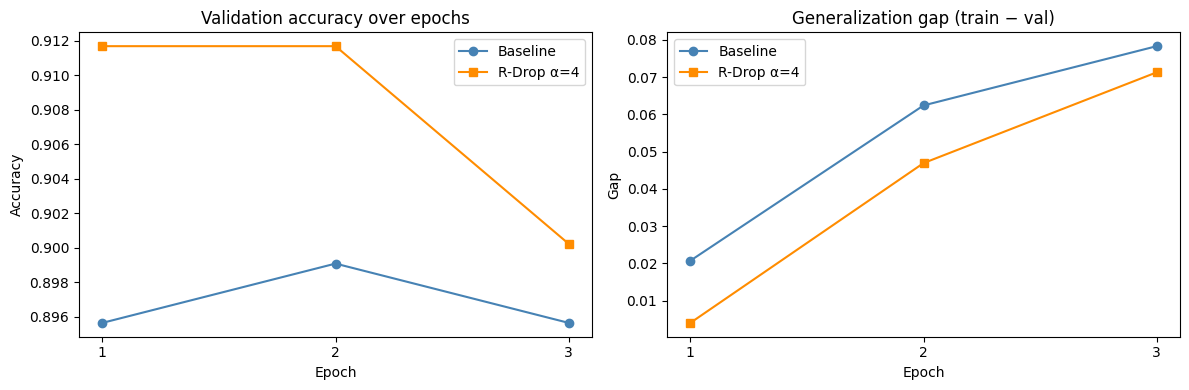


--- Summary Table ---
Epoch 1 | Baseline val=0.8956 gap=0.0207 | R-Drop val=0.9117 gap=0.0040
Epoch 2 | Baseline val=0.8991 gap=0.0624 | R-Drop val=0.9117 gap=0.0469
Epoch 3 | Baseline val=0.8956 gap=0.0783 | R-Drop val=0.9002 gap=0.0713


In [ ]:
import matplotlib.pyplot as plt

# --- Baseline ---
model_base = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2).to(device)
opt_base = AdamW(model_base.parameters(), lr=2e-5)
hist_base = train_and_track(model_base, opt_base, n_epochs=3,
                             use_rdrop=False, label="Baseline")

# --- R-Drop α=4.0 ---
model_rd = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2).to(device)
opt_rd = AdamW(model_rd.parameters(), lr=2e-5)
hist_rd = train_and_track(model_rd, opt_rd, n_epochs=3,
                           use_rdrop=True, alpha=4.0, label="R-Drop α=4")

# --- Plot learning curves ---
epochs = [1, 2, 3]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, hist_base["val_acc"], "o-", label="Baseline", color="steelblue")
axes[0].plot(epochs, hist_rd["val_acc"],   "s-", label="R-Drop α=4", color="darkorange")
axes[0].set_title("Validation accuracy over epochs")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].set_xticks(epochs)

axes[1].plot(epochs, hist_base["gen_gap"], "o-", label="Baseline", color="steelblue")
axes[1].plot(epochs, hist_rd["gen_gap"],   "s-", label="R-Drop α=4", color="darkorange")
axes[1].set_title("Generalization gap (train − val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Gap")
axes[1].legend(); axes[1].set_xticks(epochs)

plt.tight_layout()
plt.savefig("cp2_results.png", dpi=150)
plt.show()
print("\n--- Summary Table ---")
for e in range(3):
    print(f"Epoch {e+1} | Baseline val={hist_base['val_acc'][e]:.4f} gap={hist_base['gen_gap'][e]:.4f}"
          f" | R-Drop val={hist_rd['val_acc'][e]:.4f} gap={hist_rd['gen_gap'][e]:.4f}")